# **Машинное обучение 1, ПМИ ФКН ВШЭ. Бонусное домашнее задание**
##  **Основные методы оценки важности признаков для ML моделей**

В этом домашнем задании вы будете работать с данными о Всемирном отчёте о счастье (World Happiness Report). В качестве теории используйте следующие семинарские материалы: 
- [Основные методы оценки важности признаков для ML моделей](https://github.com/esokolov/ml-course-hse/blob/master/2025-fall/seminars/sem11-xai.ipynb);
- [Интерпретация по определению](https://github.com/esokolov/ml-course-hse/blob/master/2025-fall/seminars/sem11-xai.pdf).

**Общая информация**

**Дата выдачи:** 04.05.2026

**Дедлайн:** 18.05.2026 23:59MSK

**Оценивание и штрафы**

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимальная оценка за работу - 5 баллов.

Как всегда, сдача после жёсткого дедлайна невозможна. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).


**NB** В этом задании много работ, требующих вывода и размышлений. Куцые выводы, как и неэффективная реализация кода, могут негативно отразиться на оценке.



**Задания сдаются через систему anytask.** Посылка должна содержать:

Ноутбук homework-practice-xai-Username.ipynb
Username - ваша фамилия и имя на латинице именно в таком порядке.


## **Подготовительная часть**

In [71]:
!pip install shap -qU


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
!pip install -qU pyALE


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
!pip install -qU lime fat-forensics[all]


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### **Подготовка данных**

Загрузите датасет по ссылке.

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline


In [75]:
!wget  -O 'world-happiness-report-2021-prep.csv' -q 'https://www.dropbox.com/scl/fi/vn5d4awcg7n307bnewr2x/world-happiness-report-2021-prep-1.csv?rlkey=yk8sn3fblpvtu8iyc02vpryhp&st=cvysdgto&dl=0'

"wget" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.
"st" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.
"dl" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [76]:
data_to_work = pd.read_csv("world-happiness-report-2021-prep.csv")

data_to_work.head(5)


,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,7.842,10.775,0.954,72.0,0.949,-0.098,0.186,3.253
1,7.620,10.933,0.954,72.7,0.946,0.030,0.179,2.868
2,7.571,11.117,0.942,74.4,0.919,0.025,0.292,2.839
3,7.554,10.878,0.983,73.0,0.955,0.160,0.673,2.967
4,7.464,10.932,0.942,72.4,0.913,0.175,0.338,2.798


### Примечание про столбец Dystopia + residual.


В World Happiness Report Dystopia - это не реальная страна, а техническая точка отсчёта: гипотетическая страна с минимальными значениями по ключевым факторам (GDP, social support, life expectancy, freedom, generosity, corruption). Её вводят как бенчмарк, чтобы вклады факторов в разложении были неотрицательными.

Столбец `Dystopia + residual` - это  разложения: базовый уровень (оценка жизни в Dystopia) плюс остаточная часть, которую шесть факторов не объясняют для конкретной страны (ошибка/невязка модели). Это не социальный индекс, а слагаемое, которое вместе с вкладами 6 факторов даёт итоговый score.

Иначе говоря, в таблицах WHR:
Score ~ (вклады 6 факторов) + (Dystopia + residual).

### Поехали дальше

In [77]:
X = data_to_work.drop("Ladder score", axis=1)
y = data_to_work["Ladder score"]


Для обучения будем использовать два способа масштабирования - `MinMaxScaler` и `StandardScaler`.

In [78]:
feature_names = list(X.columns)

# Выберем признак для анализа
feature_idx = 1
feature_name = X.columns[feature_idx]

print(f"FEATURE TO ANALYZE: {feature_name}")


FEATURE TO ANALYZE: Social support


In [79]:
# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 1
sc_minmax = MinMaxScaler()
X_train_sc_minmax = sc_minmax.fit_transform(X_train)
X_test_sc_minmax = sc_minmax.transform(X_test)

# 2
sc_standard = StandardScaler()
X_train_sc_standard = sc_standard.fit_transform(X_train)
X_test_sc_standard = sc_standard.transform(X_test)


### **Задание 1. (0.5 балла)**
- Обучите 6 моделей:
  -  линейную регрессию (`LinearRegression`) на двух вариантах данных;
  - Lasso регрессию (`Lasso`) на двух вариантах данных;
  - градиентный бустинг (`GradientBoostingRegressor`) на двух вариантах данных;
- Выведите MSE и RMSE моделей.
- Зафиксируйте выводы.

> Цель задания - увидеть, какие модели чувствительны к масштабу признаков (Lasso), а какие почти инвариантны (LR/деревья), и почему это важно для интерпретации.


**NB:** Для бустингов ограничьте глубину до 5.

In [80]:
lr_minmax = LinearRegression()
lr_minmax.fit(X_train_sc_minmax, y_train)
y_pred = lr_minmax.predict(X_test_sc_minmax)
mse_lr_minmax = mean_squared_error(y_test, y_pred)
print("LinearRegression MinMax  MSE:", mse_lr_minmax, " RMSE:", np.sqrt(mse_lr_minmax))

lr_standard = LinearRegression()
lr_standard.fit(X_train_sc_standard, y_train)
y_pred = lr_standard.predict(X_test_sc_standard)
mse_lr_standard = mean_squared_error(y_test, y_pred)
print("LinearRegression Standard  MSE :", mse_lr_standard, " RMSE:", np.sqrt(mse_lr_standard))

lasso_minmax = Lasso(alpha=0.01, max_iter=4000)
lasso_minmax.fit(X_train_sc_minmax, y_train)
y_pred = lasso_minmax.predict(X_test_sc_minmax)
mse_lasso_minmax = mean_squared_error(y_test, y_pred)
print("Lasso MinMax  MSE:", mse_lasso_minmax, " RMSE:", np.sqrt(mse_lasso_minmax))

lasso_standard = Lasso(alpha=0.01, max_iter=4000)
lasso_standard.fit(X_train_sc_standard, y_train)
y_pred = lasso_standard.predict(X_test_sc_standard)
mse_lasso_standard = mean_squared_error(y_test, y_pred)
print("Lasso Standard  MSE:", mse_lasso_standard, " RMSE:", np.sqrt(mse_lasso_standard))

gb_minmax = GradientBoostingRegressor(max_depth=5, random_state=42, n_estimators=120)
gb_minmax.fit(X_train_sc_minmax, y_train)
y_pred = gb_minmax.predict(X_test_sc_minmax)
mse_gb_minmax = mean_squared_error(y_test, y_pred)
print("GBR MinMax  MSE:", mse_gb_minmax, " RMSE:", np.sqrt(mse_gb_minmax))

gb_standard = GradientBoostingRegressor(max_depth=5, random_state=42, n_estimators=120)
gb_standard.fit(X_train_sc_standard, y_train)
y_pred = gb_standard.predict(X_test_sc_standard)
mse_gb_standard = mean_squared_error(y_test, y_pred)
print("GBR Standard  MSE:", mse_gb_standard, " RMSE:", np.sqrt(mse_gb_standard))


LinearRegression MinMax  MSE: 9.8419022351019e-07  RMSE: 0.0009920636186808737
LinearRegression Standard  MSE : 9.841902235101707e-07  RMSE: 0.000992063618680864
Lasso MinMax  MSE: 0.0074930554133732594  RMSE: 0.08656243650321575
Lasso Standard  MSE: 0.00034431902429403493  RMSE: 0.018555835316526038
GBR MinMax  MSE: 0.15305825293006695  RMSE: 0.391226600488856
GBR Standard  MSE: 0.15304748149176917  RMSE: 0.39121283400697526


## **1. Интерпретация по определению**

Воспользуемся встроенными важностями в моделях. Для бустинга — усредненная важность по деревьям, для регрессий — коэффициенты.

### **Задание 2. (0.25 балла)**
- Постройте график (любой, на ваш выбор), позволяющий визуально оценить и сравнить коэффициенты по парам моделей:
  - Модель и `StandardScaler` vs Модель и `MinMaxScaler`
- Зафиксируйте выводы по каждой из пар графиков.

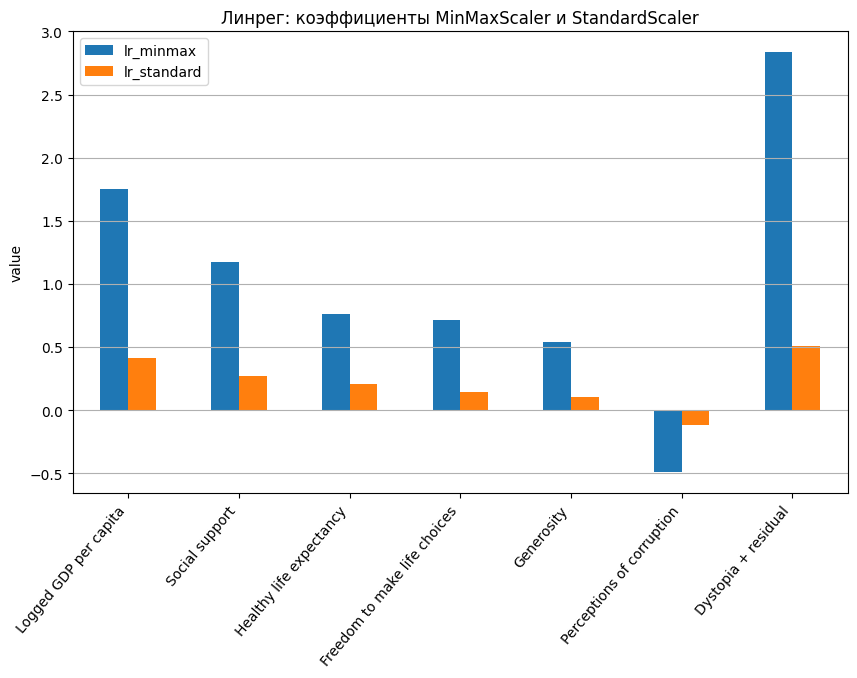

In [81]:
lr_coef_df = pd.DataFrame(
    {"lr_minmax": lr_minmax.coef_, "lr_standard": lr_standard.coef_},
    index=feature_names,
)

lr_coef_df.plot(kind="bar", figsize=(10, 6))
plt.title("Линрег: коэффициенты MinMaxScaler и StandardScaler")
plt.ylabel("value")
plt.xticks(rotation=50, ha="right")
plt.grid(axis="y")
plt.show()


**Ваш вывод здесь:** 
1) **LR** - набор важных признаков остался такой же, самые важные: `Dystopia + residual`, `Logged GDP per capita` и `Social support`. `Perceptions of corruption` - он имеет отрицательный вес, ну оно и понятно. При StandardScaler и MinMaxScaler значение параметров сильно отличаются, потому что у них была разная нормировка и они лежат в разных диапазонах. Качество +- одинаковое у них разница супер маленькая

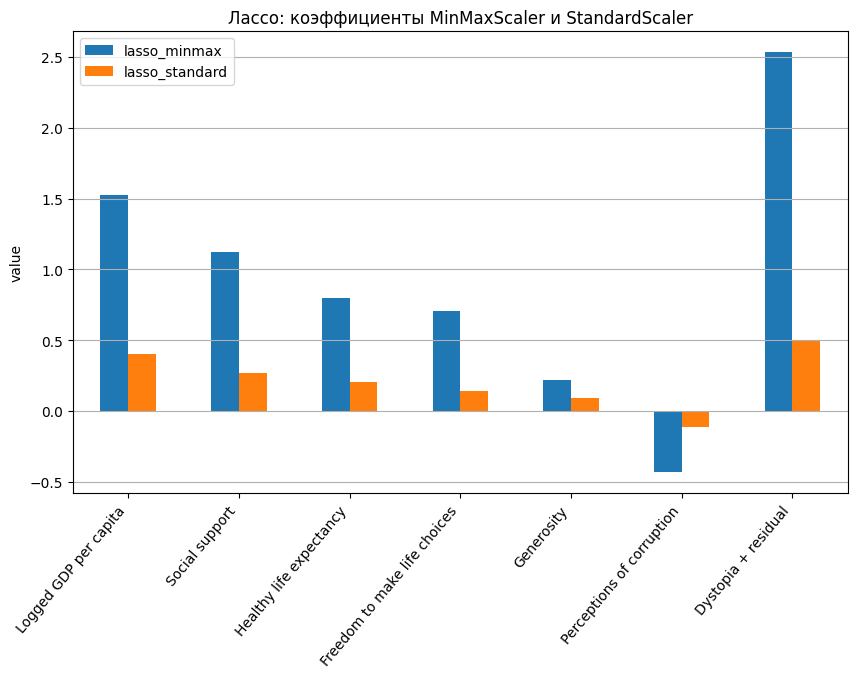

In [82]:
lasso_coef_df = pd.DataFrame(
    {"lasso_minmax": lasso_minmax.coef_, "lasso_standard": lasso_standard.coef_},
    index=feature_names,
)

lasso_coef_df.plot(kind="bar", figsize=(10, 6))
plt.title("Лассо: коэффициенты MinMaxScaler и StandardScaler")
plt.ylabel("value")
plt.xticks(rotation=50, ha="right")
plt.grid(axis="y")
plt.show()


**Ваш вывод здесь:**

 **Lasso** - ситуация такая же как и при LR, но все коэфы при MinMaxScaler чуть поменьше, потому что мы применили к ним регуляризацию и это было очевидно. Коэфы для StandardScaler буквально такие же как и при обычной LR. поэтому все выводы по признакам и качество см. выше

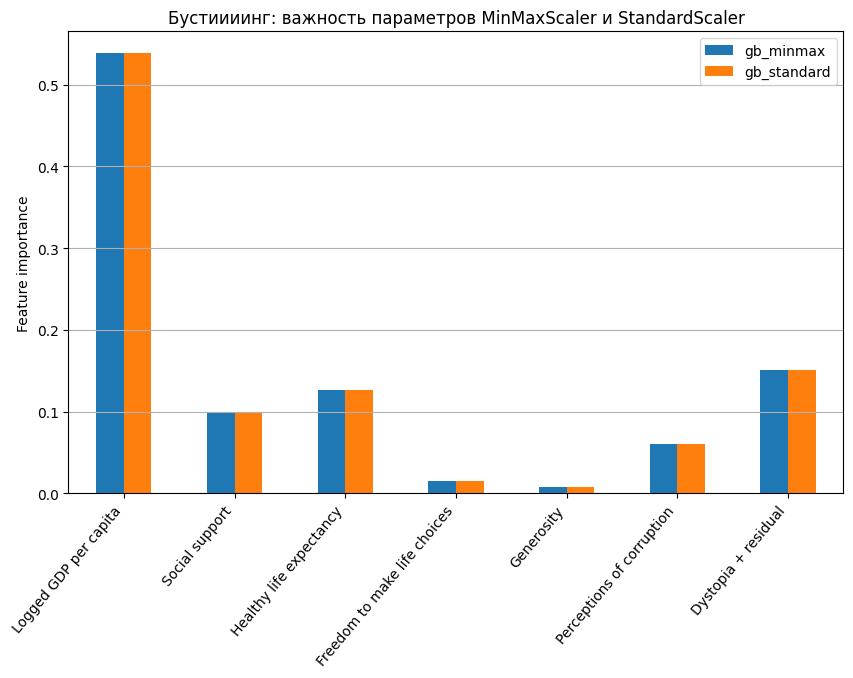

In [83]:
gb_importance_df = pd.DataFrame(
    {
        "gb_minmax": gb_minmax.feature_importances_,
        "gb_standard": gb_standard.feature_importances_,
    },
    index=feature_names,
)

gb_importance_df.plot(kind="bar", figsize=(10, 6))
plt.title("Бустиииинг: важность параметров MinMaxScaler и StandardScaler")
plt.ylabel("Feature importance")
plt.xticks(rotation=50, ha="right")
plt.grid(axis="y")
plt.show()


**Ваш вывод здесь:** 
 **GB** - тут я смотрел важность параметров. Важность каждого параметра совпадает между StandardScaler и MinMaxScaler. Это было очевидно, потому что под капотом у нас деревья, а им не важно на линейные преобразования. Самым важным признаком для бустинга оказался `Logged GDP per capita`. Масштабирование не роляет на бустинг

### **Задание 3. (0.25 балла)**
Вернитесь к графику линейной регрессии. Очевидно, что коэффициенты одной модели связаны с коэффициентами другой. Как перейти от одних к другим? Реализуйте это в коде, как для свободного члена, так и для самих коэффициентов.

> Идея: коэффициенты линейной модели можно сравнивать как важности только при фиксированном масштабе. Вывод формулы перехода - способ строго показать, что коэффициенты меняются предсказуемо и не являются абсолютной важностью.

**Ваши теоретические выкладки здесь:** пупупу

In [84]:
results = {"lr_standard": [lr_standard]}

coef_std = lr_minmax.coef_ * (sc_standard.scale_ / sc_minmax.data_range_)
intercept_std = lr_minmax.intercept_ + np.sum(
    lr_minmax.coef_ * (sc_standard.mean_ - sc_minmax.data_min_) / sc_minmax.data_range_
)

assert round(intercept_std, 4) == round(results["lr_standard"][0].intercept_, 4)
assert all(np.round(coef_std, 4) == np.round(results["lr_standard"][0].coef_, 4))


## **1. Plot-based методы**

Рассмотрев тонкости работы с масштабированием, поработаем с plot-based методами. Оставьте теперь для анализа линейную регрессию и бустинг, обученные на MinMaxScaler.

In [85]:
lr_minmax = lr_minmax
gb_minmax = gb_minmax


### **1. 1. ICE**

**Построение:**

1. Зафиксируем множество $X_{test}$ и некоторый признак $j$. Пусть  $j$ имеет $m$ уникальных значений $[j_1, j_2, ..., j_m]$.

2. Исходный датасет  $X_{test}$ дублируем  $m$ раз: $$X'_1, X'_2, ..., X'_m,$$ так, что для датасета $X'_i$ значение признака $j$ есть $j_i$;

3. На каждом $X'_i$ рассчитываем прогноз модели $f(X'_i)$&

4. На графике строим линии для каждого объекта, показывающие как прогноз (ось $y$) меняется при изменении признака (ось $x$);

### **Задание 4. (0.5 балла)**

Мы знаем, что признаки модели масштабированы определенным образом. Минимум каждого признака равен 0, максимум 1. Что будет с моделями, если признаки выйдут из диапазона?
- Работая с тем же признаком, изучите его **исходные** минимум и максимум. Сделайте искусственный диапазон из 20 точек, равный $[max, 3*max]$.
- На полученном диапазоне постройте ICE для обеих моделей. ICE стройте собственноручно, без использования sklearn.
- Зафиксируйте выводы


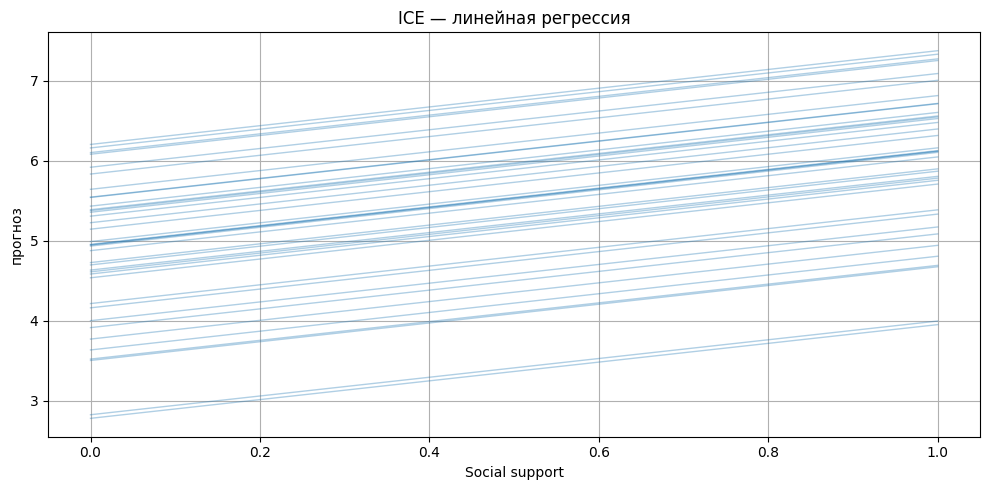

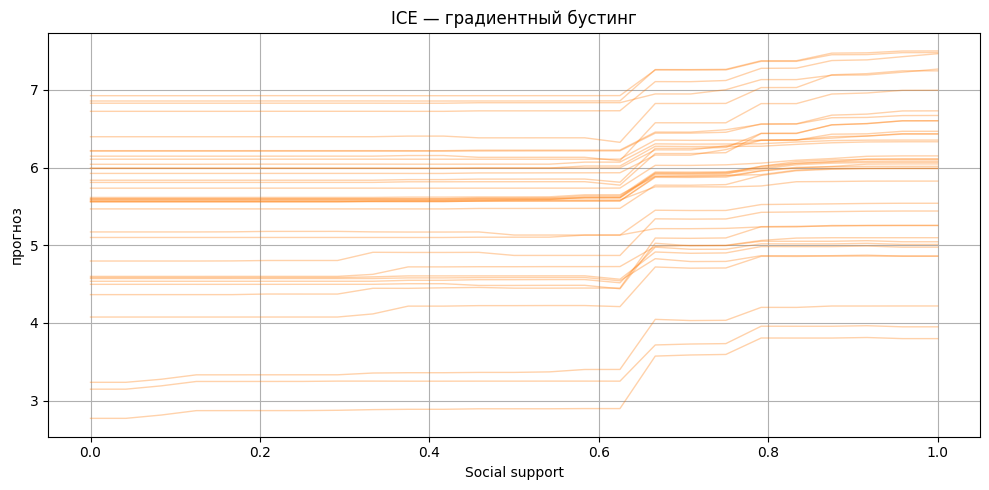

In [103]:
j = feature_idx

lo = X_train_sc_minmax[:, j].min()
hi = X_train_sc_minmax[:, j].max()
grid = np.linspace(lo, hi, 25)

plt.figure(figsize=(10, 5))
for row in range(X_test_sc_minmax.shape[0]):
    x_one = X_test_sc_minmax[row].copy()
    y_line = []
    for v in grid:
        x_one[j] = v
        y_line.append(lr_minmax.predict(x_one.reshape(1, -1))[0])
    plt.plot(grid, y_line, color="tab:blue", alpha=0.35, linewidth=1)

plt.title("ICE — линейная регрессия")
plt.xlabel(feature_name)
plt.ylabel("прогноз")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for row in range(X_test_sc_minmax.shape[0]):
    x_one = X_test_sc_minmax[row].copy()
    y_line = []
    for v in grid:
        x_one[j] = v
        y_line.append(gb_minmax.predict(x_one.reshape(1, -1))[0])
    plt.plot(grid, y_line, color="tab:orange", alpha=0.35, linewidth=1)

plt.title("ICE — градиентный бустинг")
plt.xlabel(feature_name)
plt.ylabel("прогноз")
plt.grid(True)
plt.tight_layout()
plt.show()


**Ваш вывод здесь:** 

1) Исходно у линейной модели max и min были 1 и 0 соответственно, потом мы сдвинули все от 1 до 3, и взяли 20 точек, окей. Видно, что прямые продолжают расти, модель думает что и за пределами нашего диапазона данные будут иметь такую же природу. Это означает что модель умеет экстраполировать данные за пределами обучающего диапазона

2) Дерево же не умеет экстраполировать и поэтому дает константу. Потому что дерево - нелинейная модель и она знает только train и делает параллельные разрезы на train, деревья не умеют делать разрезы под углом и поэтому бустинг на деревьях не будет экстраполировать. 

### **1. 2. PDP**

Теперь посмотрим на усредненнуе влияние признака.
### **Задание 5. (0.25 балла)**

- Усредните ICE по обеим моделям, используя PDP из sklearn.
- Сделайте выводы.


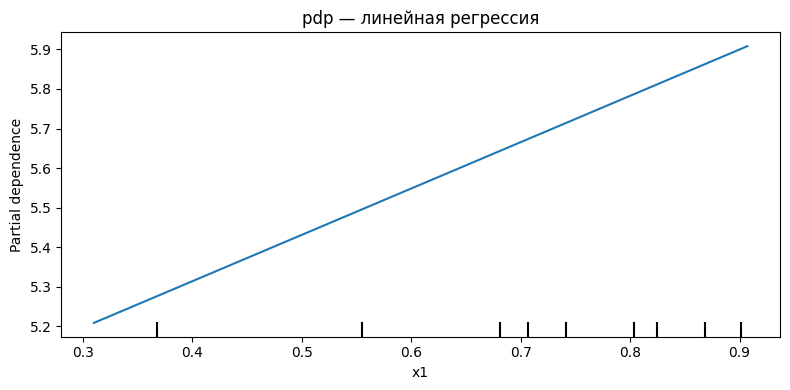

In [106]:
j = feature_idx

fig, ax = plt.subplots(figsize=(8, 4))
PartialDependenceDisplay.from_estimator(
    lr_minmax,
    X_test_sc_minmax,
    features=[j],
    grid_resolution=25,
    ax=ax,
)
ax.set_title("pdp — линейная регрессия")
ax.set_xlabel(feature_name)
ax.set_ylabel("прогноз")
plt.tight_layout()
plt.show()


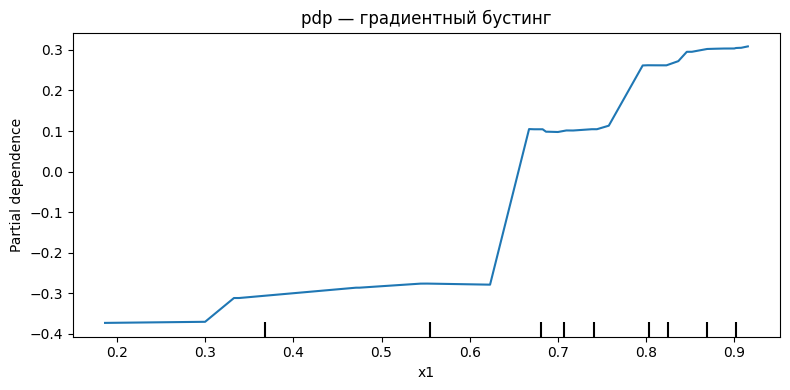

In [105]:
j = feature_idx

fig, ax = plt.subplots(figsize=(8, 4))
PartialDependenceDisplay.from_estimator(
    gb_minmax,
    X_test_sc_minmax,
    features=[j],
    grid_resolution=50,
    ax=ax,
)
ax.set_title("pdp — градиентный бустинг")
ax.set_xlabel(feature_name)
ax.set_ylabel("средний прогноз")
plt.tight_layout()
plt.show()


**Ваш вывод здесь:** **Ваш вывод здесь:**

1) У линейной модел и при увеличении `Social support` будет предсказание будет линейно расти. Это понятно потому что линейная регрессия задает линейную зависимость между признаком и ответом

2) У бустинга график же нелинейный, но возрастающий, потому что бустинг построен на деревьях и они не являются линейными. Значение сильно растет при определнных порогах, один из таких это 0.63  при этой отметке значение признака `Social support` итоговая метрика сильно возрастает. P.S(я поставил 400 точек, чтобы точно найти пики и чем больше точек тем более плавный в итоге будет график, но есть предел он около 100 точек, дальше всегда одинаковый график)

### **1. 3. Accumulated Local Effects (ALE)**

Заключительный из основных графических методов — ALE. Ради практики построим и его.

### **Задание 6. (0.5 балла)**

- Постройте ALE по обеим моделям, используя pyALE. (0.15)
- Подберите размер сетки так, чтобы получить доверительные интервалы. (0.05)
- Проанализируйте полученный график. Каковы получились ДИ? Почему они различны для моделей? (0.3)

> Важно: сетку значений строим в исходных единицах признака, но перед подачей в модель применяем тот же scaler, на котором обучение.

PyALE._ALE_generic:INFO: Continuous feature detected.


,eff,size,lowerCI_95%,upperCI_95%
Social support,,,,
0.560,-0.599710,0.0,NaN,NaN
0.619,-0.466790,2.0,-0.466790,-0.466790
0.636,-0.428491,1.0,NaN,NaN
0.639,-0.421732,1.0,NaN,NaN
0.708,-0.266284,1.0,NaN,NaN
0.710,-0.261778,1.0,NaN,NaN
0.746,-0.180675,1.0,NaN,NaN
0.750,-0.171663,1.0,NaN,NaN
0.787,-0.088307,1.0,NaN,NaN


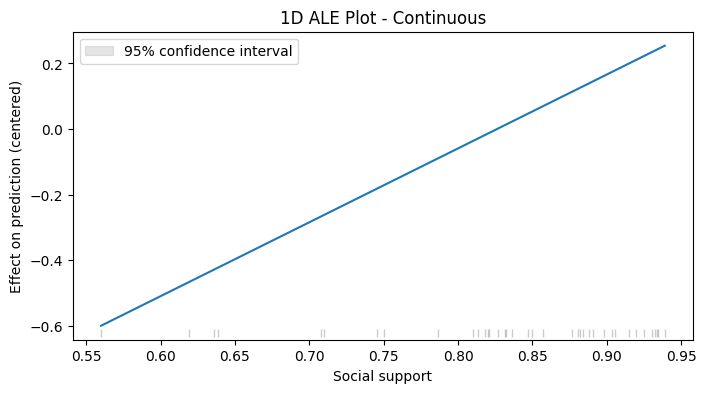

In [ ]:
from PyALE import ale

lr_pipe = make_pipeline(sc_minmax, lr_minmax)
gb_pipe = make_pipeline(sc_minmax, gb_minmax)

#алёёё
ale_lr = ale(X=X_test, model=lr_pipe, feature=[feature_name], grid_size=40)
ale_lr


PyALE._ALE_generic:INFO: Continuous feature detected.


,eff,size,lowerCI_95%,upperCI_95%
Social support,,,,
0.560,-0.234372,0.0,NaN,NaN
0.619,-0.231845,2.0,-0.263953,-0.199738
0.636,-0.238341,1.0,NaN,NaN
0.639,-0.238341,1.0,NaN,NaN
0.708,-0.230281,1.0,NaN,NaN
0.710,-0.230281,1.0,NaN,NaN
0.746,-0.229071,1.0,NaN,NaN
0.750,-0.229071,1.0,NaN,NaN
0.787,-0.226522,1.0,NaN,NaN


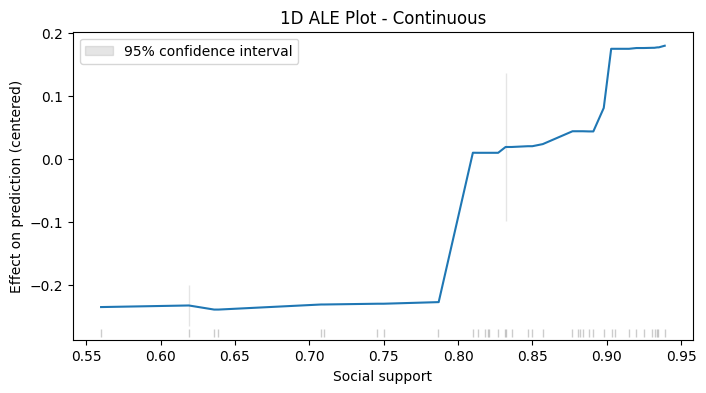

In [ ]:

#aлёёёёёёёё   ладно, извините
ale_gb = ale(X=X_test, model=gb_pipe, feature=[feature_name], grid_size=40)
ale_gb


**Ваши выводы здесь:** 

1) Для `LinearRegression` зависимость получилась почти линейной: чем выше `Social support`, тем выше предсказание. Это ожидаемо, потому что линейная регрессия задаёт прямую зависимость между признаком и ответом.

2) Для `GradientBoostingRegressor` график получился нелинейным и ступенчатым. Это связано с тем, что бустинг основан на деревьях решений и меняет предсказание при переходе через определённые пороги признака.

Обе модели показывают положительное влияние `Social support`. Доверительные интервалы показывают неопределённость оценки эффекта.

## **2. Permutation importances**

Практикуем ещё один метод.
### **Задание 7. (0.25 балла)**

- Постройте Permutation importances по обеим моделям, используя sklearn
- Поэкспериментируйте с числом перестановок. (0.05)
- Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов? Зафиксируйте выводы. (0.20)

In [91]:
from sklearn.inspection import permutation_importance

perm_lr_5 = permutation_importance(
    lr_minmax, X_test_sc_minmax, y_test, n_repeats=5, random_state=42, scoring="neg_mean_squared_error"
)
perm_gb_5 = permutation_importance(
    gb_minmax, X_test_sc_minmax, y_test, n_repeats=5, random_state=42, scoring="neg_mean_squared_error"
)

perm_lr_20 = permutation_importance(
    lr_minmax, X_test_sc_minmax, y_test, n_repeats=20, random_state=42, scoring="neg_mean_squared_error"
)
perm_gb_20 = permutation_importance(
    gb_minmax, X_test_sc_minmax, y_test, n_repeats=20, random_state=42, scoring="neg_mean_squared_error"
)

perm_lr_df = pd.DataFrame({"feature": feature_names, "importance": perm_lr_5.importances_mean})
perm_gb_df = pd.DataFrame({"feature": feature_names, "importance": perm_gb_5.importances_mean})


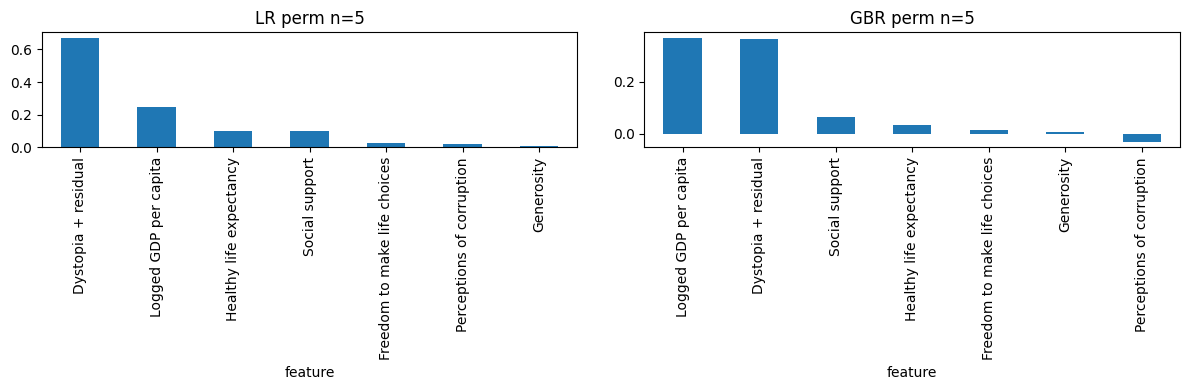

In [92]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
perm_lr_df.sort_values("importance", ascending=False).set_index("feature")["importance"].plot(
    kind="bar", ax=ax[0], title="LR perm n=5"
)
perm_gb_df.sort_values("importance", ascending=False).set_index("feature")["importance"].plot(
    kind="bar", ax=ax[1], title="GBR perm n=5"
)
plt.tight_layout()
plt.show()


**Ваши выводы здесь:** 

1) Для линейной модели самым важным стал `Dystopia + residual`. Остальные слабее

2) Для бустинга же самыми важными стали `Dystopia + residual` и `Logged GDP per capita`. Остальные сильно сильно слбаее

При увеличении числа перемешиваний почти ничего не меняется, я ставил и 200 и 400. Знчит что оценка важности признаков стабильна. При большем числе перестановок стандартное отклонение лучше показывает разброс оценки важности признака.


### **Задание 8. (0.5 балла)**

Идея перестановочной важности представляет собой частный случай важности при помощи внесения **возмущений** в признак. Возмущения могут быть разных видов:

- внесение случайного шума;
- зануление признака (удобно для изображений);
- сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели;

В этом задании попробуем построить оценку на основе сдвига к базовому значению траектории. Примем за базовое значение медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:

$$x_j^{(\beta)}=(1-\beta)x_j+\beta b_j$$

где $b_j$ – медиана признака. Важность будем оценивать как изменение MSE по тест-данным.

1. Реализуйте это возмущение. Как меняются важности при разных $\beta$?
2. Постройте bar-график и сравните ранжирование с **permutation importance**. При сравнении, анализируйте только числовые признаки.


Для регрессии эффект очевиден, поэтому эту окклюзию оценивайте только для бустинга.
**Подсказка:**

1. Выберите базовые значения $x_j$ как **медианы по train** (базовые значения обозначим за $b_j$);
2. На тренировочном наборе данных для каждого признака $j$ замените столбец $x_j$ на $x^{(\beta)}_j=(1-\beta)x_j+\beta b_j$ при разных $\beta$, равных $[0.2, 0.5, 1]$.
3. Посчитайте $\Delta L_j = \text{MSE}(y,\hat y^{(\beta)}_j)-\text{MSE}(y,\hat y)$. Чем больше $\Delta L_j$, тем важнее признак.



In [93]:
def occlusion_importance():
    gb_pipe = make_pipeline(sc_minmax, gb_minmax)
    base_values = X_train.median()
    base_pred = gb_pipe.predict(X_test)
    base_mse = mean_squared_error(y_test, base_pred)
    results = []
    for beta in [0.2, 0.5, 1.0]:
        for feature in X_test.columns:
            X_changed = X_test.copy()
            X_changed[feature] = (1 - beta) * X_changed[feature] + beta * base_values[feature]
            y_pred_changed = gb_pipe.predict(X_changed)
            changed_mse = mean_squared_error(y_test, y_pred_changed)
            results.append({"feature": feature, "beta": beta, "importance": changed_mse - base_mse})
    return pd.DataFrame(results)


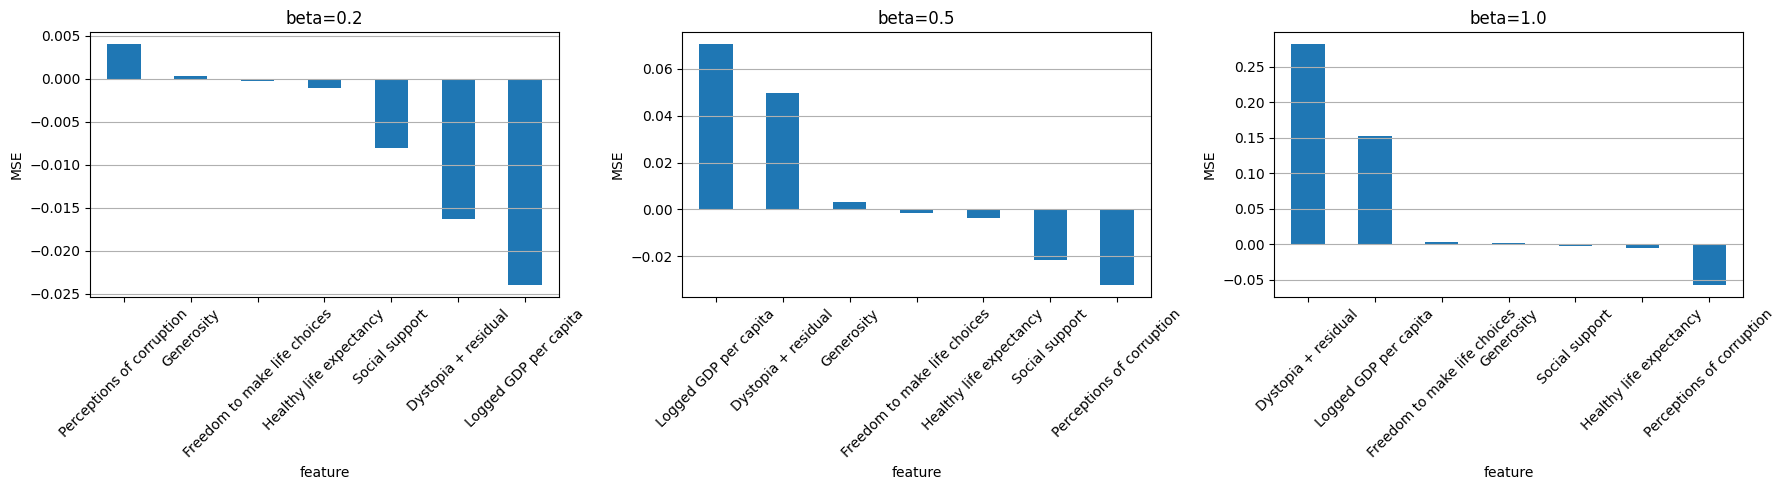

In [94]:
occlusion_df = occlusion_importance()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, beta in zip(axes, [0.2, 0.5, 1.0]):
    sub = occlusion_df[occlusion_df["beta"] == beta].sort_values("importance", ascending=False)
    sub.set_index("feature")["importance"].plot(kind="bar", ax=ax)
    ax.set_title(f"beta={beta}")
    ax.set_ylabel("MSE")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y")
plt.tight_layout()
plt.show()


**Ваши выводы здесь:**

Было сказано анализировать только числовые признаки, но они у меня все числовые

1) beta = 0.2 видно, что возмущение слабое: (0.005). Но более важно, что есть отрицательные столбцы - это значит что сдвиг этих признаков к медиане, даже улучшил качество модели

2) beta = 0.5 видно, что возмущение уже посильнее: (0.06) в десять раз увеличилось, при сдвиге `Logged GDP` или `Dystopia + residiual` растет MSE. Есть также отрицательные: `Social support` и `Perceptions of corruption` они дают небольшое улучшение

3) beta = 1. очень сильное возмещение и видно два самых вырожденных признака: `Logged GDP` или `Dystopia + residiual` при сдвиге их к медиане MSE сильно растет, это означает что бустинг использует в основном эти признаки, чтобы давать предсказания

## **3. SHAP**

Теперь проведем локальный анализ, используя SHAP и LIME. Но для shap также построим глобальные графики.

### **Задание 9. (0.5 баллa)**
- Постройте два глобальных графика, используя SHAP. Как один из них обязательно используйте `force`, как другой — выберите любой из документации. (0.25 балл)
- Проанализируйте важность признаков в обоих алгоритмах.(0.25 балл)

**NB:** Для линейного алгоритма используйте masker=`shap.maskers.Independent(data=X_train_sc)`. Он имитирует отсутствие признака

In [95]:
import shap

shap.initjs()

X_train_sc_df = pd.DataFrame(X_train_sc_minmax, columns=X.columns)
X_test_sc_df = pd.DataFrame(X_test_sc_minmax, columns=X.columns)

masker = shap.maskers.Independent(data=X_train_sc_df)
explainer_lr = shap.Explainer(lr_minmax.predict, masker)
shap_values_lr = explainer_lr(X_test_sc_df)

explainer_gb = shap.TreeExplainer(gb_minmax)
shap_values_gb = explainer_gb(X_test_sc_df)

shap.plots.force(shap_values_lr[:80])


c:\Users\tav81\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
c:\Users\tav81\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
c:\Users\tav81\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
c:\Users\tav81\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
c:\Users\tav81\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearR

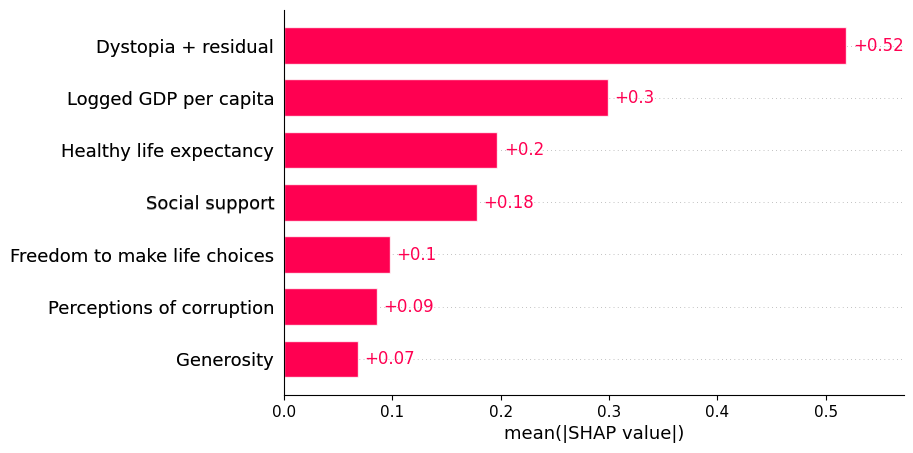

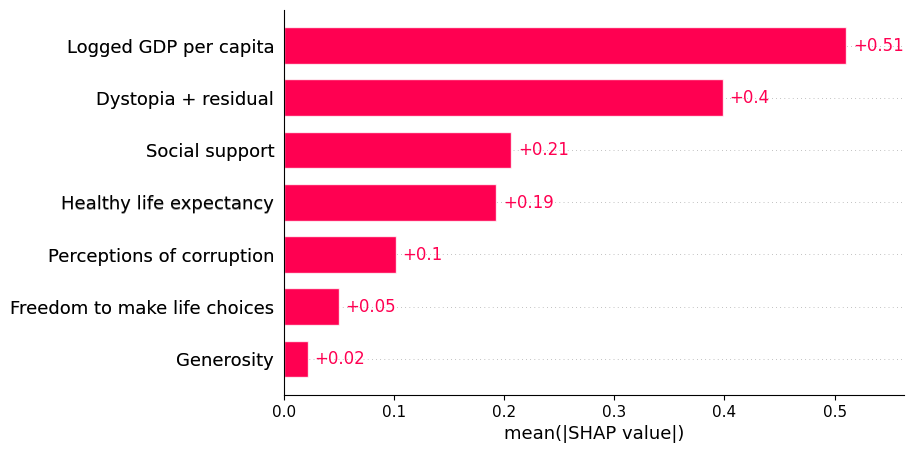

In [96]:
shap.plots.force(shap_values_gb[:50])
shap.plots.bar(shap_values_lr)
shap.plots.bar(shap_values_gb)


 **Ваш вывод здесь:**

  На графиках force я почти ничего не понял, но вот на bar все гораздо легче понять

 1) Для линейной модели самым важным был `Dystopia + residual`. На втором месте был `Logged GDP per capita`. Дальше два признака по 0.2 и остальные крохи. Это означает что линейная модель больше всего опирается на первый и второй признак(который на первом и втором месте соответственно)

 2) Для бустинга есть два признака, которые на первом месте: `Logged GDP per capita` и `Dystopia + residual`, остальные тоже дают вклад, но не такой большой, также есть два признака, которы дают совсем крохи (0.05 и 0.02)

 Можно заметить что модели выбирают +- похожие признаки, на которые опираются больше всего, это означает что эти признаки реально несут в себе бОльшую часть информации

## **Локальное объяснение.**

### **Задание 10. (0.25 балла)**
- Постройте локальный график с SHAP для объекта с индексом 7 на обеих моделях и сделайте выводы.

In [97]:
shap.plots.force(shap_values_lr[7])


In [98]:
shap.plots.force(shap_values_gb[7])


**Ваш вывод здесь:**


Тут уже можно понять

1) Для линейной модели сильнее всего уменьшает прогноз `Dystopia + residual` и `Logged GDP per capita`, потому что у них самая большая длина на графике. На третьем месте `Freedom to make life...` лень писать

2) Для бустинга сильнее всего уменьшает прогноз `Dystopia + residual` и `Logged GDP per capita`, потому что у них самая большая длина на графике. На третьем месте `Healthy life...`. НО тут есть `Social support`, который дает плюс

### **Теория: SHAP + categorical**


SHAP разлагает предсказание модели $f(x)$ на базовый уровень $\phi_0=\mathbb E[f(X)]$ и сумму вкладов признаков:

$$
f(x)=\phi_0+\sum_{j=1}^p \phi_j(x).
$$

Значение $\phi_j(x)$ — это «маржинальный вклад» признака $j$ вблизи точки $x$, усреднённый по всем коалициям признаков. Сумма SHAP по признакам всегда совпадает с предсказанием относительно базовой линии — отсюда удобство интерпретации и сравнимость вкладов.

Однако, вопреки этому удобству, SHAP имеет ограничения при работе с категориальными данными в разных кодировках.


1. OneHotEncoding. В этом случае каждому столбцу присвается свое значение Шепли. Общий вклад здесь — всегда **сумма** dummy-столбцов.
2. В CatBoost используется особый способ категориального разбиения, который (при использовании) фактически создаёт новые признаки для разбиения, отсутствующие в исходном наборе входных признаков. Эти признаки позволяют разбивать целые группы категорий тем или иным образом. Поддержка таких типов деревьев пока не реализована в SHAP, но можно использовать в CatBoost — встроенные [ShapValues](https://catboost.ai/docs/en/concepts/shap-values).
3. При других типах кодировок важно проверять отсутствие утечки.



## **4. LIME**

### **Задание 11. (0.25 балла)**
- Постройте локальный график с LIME для объекта с индексом 7 на обеих моделях и сделайте выводы. Сравните графики с SHAP. Ядро используйте как в семинаре — `kernel_width=np.sqrt(len(feature_names)) * 0.75`

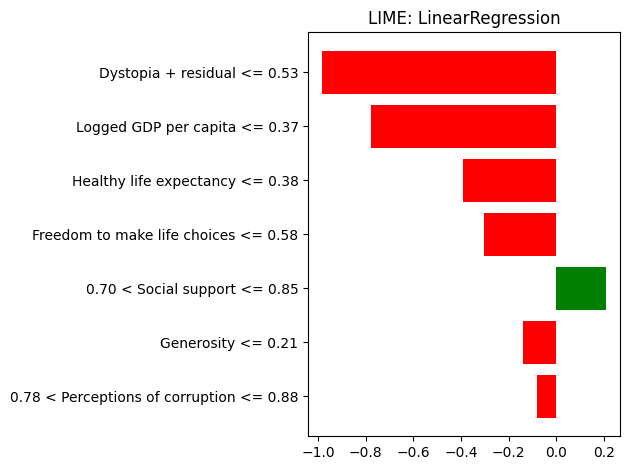

In [99]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=X_train_sc_minmax,
    feature_names=feature_names,
    mode="regression",
    kernel_width=np.sqrt(len(feature_names)) * 0.75,
)

x_obj = X_test_sc_minmax[7]
exp_lr = explainer.explain_instance(
    data_row=x_obj,
    predict_fn=lr_minmax.predict,
    num_features=len(feature_names),
)
fig = exp_lr.as_pyplot_figure()
plt.title("LIME: LinearRegression")
plt.tight_layout()
plt.show()


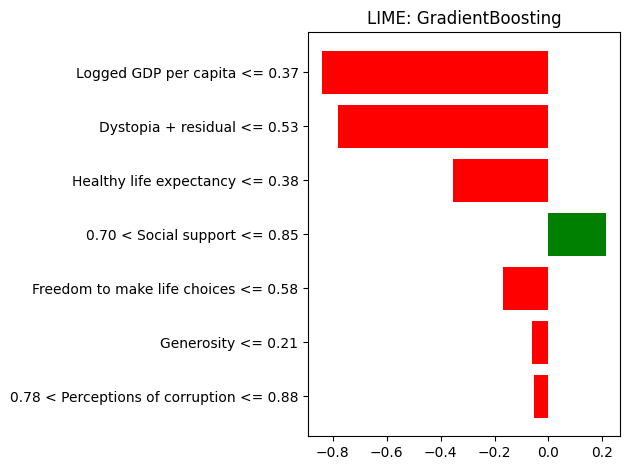

In [100]:
exp_gb = explainer.explain_instance(
    data_row=x_obj,
    predict_fn=gb_minmax.predict,
    num_features=len(feature_names),
)
fig = exp_gb.as_pyplot_figure()
plt.title("LIME: GradientBoosting")
plt.tight_layout()
plt.show()


### **Задание 12. (1 балл)**

Теперь сделаем LIME собственноручно. Ваша реализация должна:

- Принимать на вход точку `x0`
- Вокруг этой точки данных сэмплировать окрестность заданного размера `n`
- На данных из этой окрестности получать прогнозы объясняемой модели (учитывать веса объектов, используя ядро)
- Обучать LIME модель в виде стандартной линейной регрессии
- Возвращать коэффициенты локальной модели


Для своей реализации оцените устойчивость. Как влияет на коэффициенты количество сгенерированных точек? А выбор ядра?

**В реализации вам может помочь библиотека `fatf`**
**Свой LIME тестируйте только для бустинга.**

In [101]:
def my_lime(model, x0, n=1000, kernel_width=None):
    d = len(x0)
    if kernel_width is None:
        kernel_width = np.sqrt(d) * 0.75
    X_near = np.random.normal(x0, 0.1, size=(n, d))
    X_near = np.clip(X_near, 0, 1)
    y_near = model.predict(X_near)
    distances = np.linalg.norm(X_near - x0, axis=1)
    weights = np.exp(-(distances**2) / (kernel_width**2))
    local_model = LinearRegression()
    local_model.fit(X_near, y_near, sample_weight=weights)
    return local_model.coef_


                        feature      coef
1                Social support  2.079891
6           Dystopia + residual  1.459666
5     Perceptions of corruption -1.078168
0         Logged GDP per capita  1.003303
3  Freedom to make life choices  0.405246
2       Healthy life expectancy  0.299459
4                    Generosity  0.218181


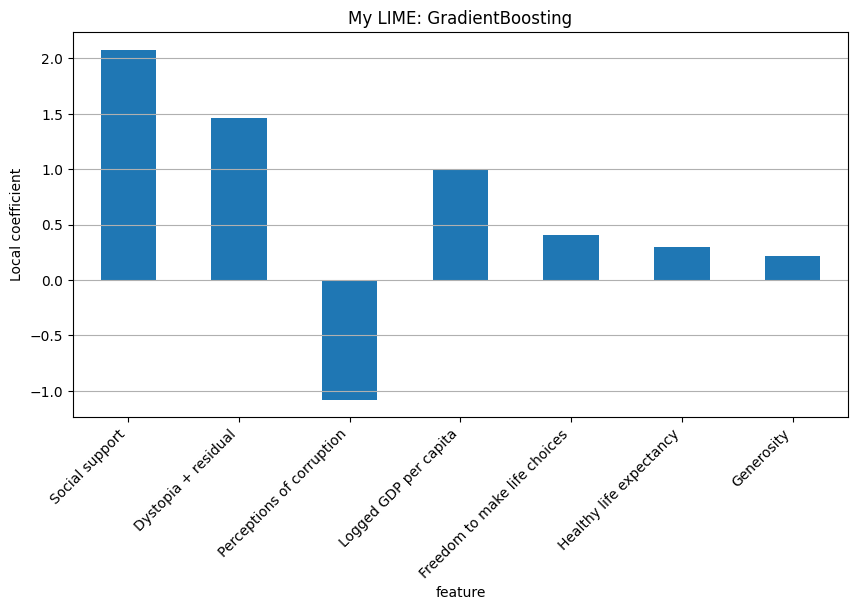

In [102]:
x0 = X_test_sc_minmax[7]
coef_lime = my_lime(
    model=gb_minmax,
    x0=x0,
    n=1000,
    kernel_width=np.sqrt(len(feature_names)) * 0.75,
)

lime_df = pd.DataFrame({"feature": feature_names, "coef": coef_lime}).sort_values(
    "coef", key=abs, ascending=False
)
print(lime_df)

lime_df.set_index("feature")["coef"].plot(kind="bar", figsize=(10, 5))
plt.title("My LIME: GradientBoosting")
plt.ylabel("Local coefficient")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()


**Ваш вывод здесь:** Для одного и того же объекта (8-й в тесте) ручной LIME на бустинге даёт похожую картину, что и библиотечный LIME: сильнее всего тянут прогноз вверх **Social support** и **Dystopia + residual**, вниз — **Perceptions of corruption**. Это согласуется с глобальной важностью признаков у GB и с SHAP.

победа реально

## **Вы проделали огромную работу! Ура!**